# Real state house price prediction using Regression models

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Linear regression model
from sklearn.linear_model import LinearRegression

# Train Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
df = pd.read_csv('D:\Data Science\Dataset\Real estate.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Acer\AppData\Local\Temp\ipykernel_2812\1393760261.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\Data Science\Dataset\Real estate.csv')


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### Data Cleaning

In [66]:
# Remove unwanted columns
df = df.drop(columns=['No','X1 transaction date'])

In [67]:
df.isnull().sum()

X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


#### Box plot for detecting outliers

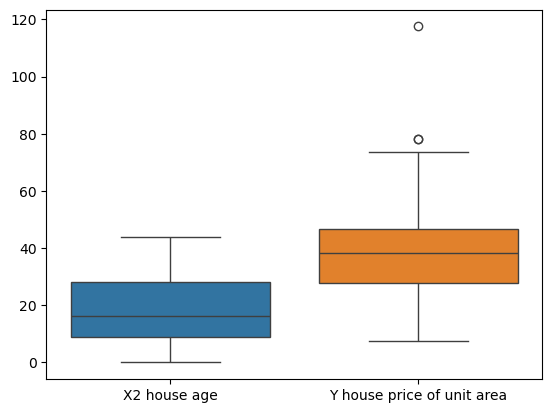

In [69]:
sns.boxplot(df[['X2 house age','Y house price of unit area']])
plt.show()

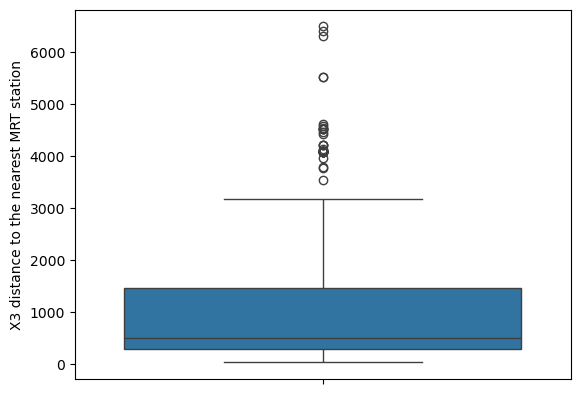

In [70]:
sns.boxplot(df['X3 distance to the nearest MRT station'])
plt.show()

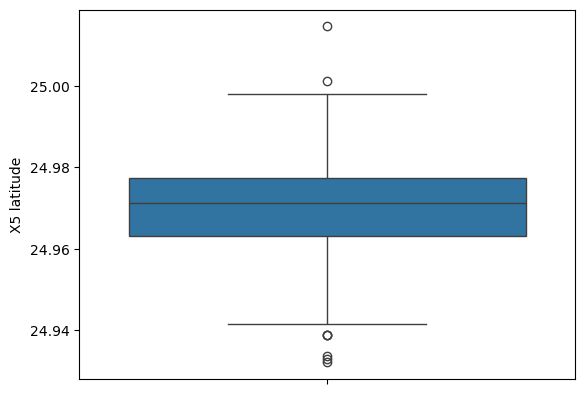

In [71]:
sns.boxplot(df['X5 latitude'])
plt.show()

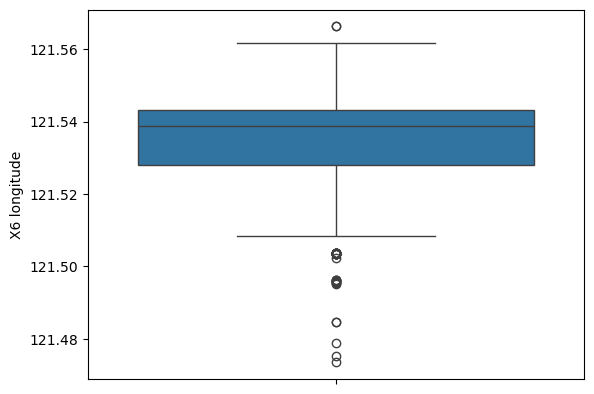

In [72]:
sns.boxplot(df['X6 longitude'])
plt.show()

In [73]:
# address data ma outlier vayepani kaile remove nagarne

# Feature and Target

In [74]:
df.columns

Index(['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [75]:
feature = ['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       ]
X= df[feature]
target = 'Y house price of unit area'
Y = df[target]

## Train Test Split

In [76]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size =0.2, random_state=42
)
# random state le data like shuffle garera 42th index dekhi 20% data lai test set banaune aru train
# test_size =0.2 means 20% test aru train so 80-20

## Feature Scaling

In [77]:
'''
(Xi-Mean)/SD
Feature Traning -> fit_transform()
    -Fit-> Learning -> Calculates mean and SD
Feature Testing -> transform()
    -Transform-> Implement -> Implements formula into data(formula from training fit ie mean and sd)
'''

'\n(Xi-Mean)/SD\nFeature Traning -> fit_transform()\n    -Fit-> Learning -> Calculates mean and SD\nFeature Testing -> transform()\n    -Transform-> Implement -> Implements formula into data(formula from training fit ie mean and sd)\n'

In [78]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

## Model Implementation

In [79]:
model = LinearRegression() #n_jobs=1 le cpu ko 1 core lai matra allocate garxa
# Train model
model.fit(X_train_scale, Y_train)

LinearRegression()

In [80]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([48.75576065, 43.18633894, 45.56849849, 42.34148729, 32.54546723,
       44.26138495, 47.25423469, 47.1743536 , 26.28813485, 53.12029712,
       34.16378368, 36.93984233, 41.67127694, 26.41744787, 37.37382674,
       34.92866986, 43.33050629, 47.85941256, 33.80337462, 45.7309244 ,
        6.99752947, 35.67123822, 49.02716419, 44.71182074, 17.34337767,
       42.31605356, 17.96387494, 45.56849849, 37.29507415, 39.20652138,
       15.25761997, 41.09840958, 39.10864993, 30.31502533, 47.21219336,
       32.8325687 , 53.30668632, 18.40038103, 48.3335622 , 41.81980886,
       37.51721389, 41.93820045, 49.67785004, 41.35635249, 43.239593  ,
       49.44385036, 46.4023015 , 26.03860515, 50.92372996, 49.43408122,
       48.75576065, 49.80975557, 42.50484004, 43.8824375 , 37.68700659,
       18.373754  , 36.46456821, 38.18872872, 32.46558615, 47.1743536 ,
       35.89460401, 34.59604573, 18.373754  , 15.43459784, 13.63522232,
       35.69786525, 31.47044663, 46.626218  , 35.65297998, 32.18

#### Calculate intercept and slope/coefficient of model

In [81]:
beta_0 = model.intercept_ #beta 0 is intercept in linear regression formula
beta_1 = model.coef_
print(f'Intercept: {beta_0}')
print(f'Coefficient/Slope: {beta_1}')

Intercept: 38.39154078549814
Coefficient/Slope: [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]


## Metrics

In [82]:
'''
Y_test-> Actual data(X-axis)
Y_pred-> Predicted data(Y-axis)
'''

'\nY_test-> Actual data(X-axis)\nY_pred-> Predicted data(Y-axis)\n'

In [83]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
print(f'Mean Absolute Error(MSE):{mae}')
print(f'Mean Squared Error(MSE):{mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{r2}')

Mean Absolute Error(MSE):5.76136382910335
Mean Squared Error(MSE):58.77654100663127
Root Mean Squared Error(RMSE/Loss Function):7.66658600725455
R2 Score(Residual Score/ Cost Function):0.6496385877630103


### Visualization (Regression Plot)

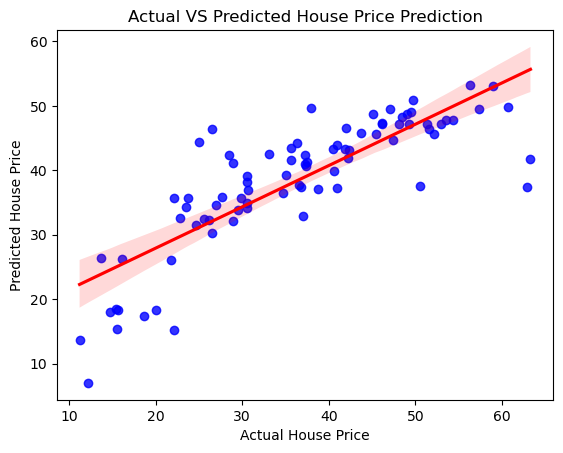

In [84]:
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual VS Predicted House Price Prediction')
plt.show()

In [85]:
# linear regression sensitive to outlier
# from above figure outlier dherai xa so outlier nahataune vaye yo data ma linear regression use garna mildaina
# line and margin vanda jati najik teti ramro